In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
import os

from datasets import load_dataset
import polars as pl

pd.set_option('display.max_columns', None)

In [2]:
pl.read_parquet('input/sample.parquet').head(5)

main_date,report_date,year,quarter,inn,ogrn,region_taxcode,creation_date,dissolution_date,age,eligible,exemption_criteria,financial,filed,imputed,simplified,articulated,totals_adjustment,outlier,okved,okved_section,okpo,okopf,okogu,okfc,oktmo,lon,lat,geocoding_quality,region_code,company_size,region,oktmo_explain,okopf_explain,okogu_explain,okfc_explain,okved_explain,…,line_4319,line_431x,line_4320,line_4321,line_4322,line_4323,line_4329,line_432x,line_4400,line_4450,line_4490,line_4500,line_6100,line_6200,line_6210,line_6215,line_6220,line_6230,line_6240,line_6250,line_6300,line_6310,line_6311,line_6312,line_6313,line_6320,line_6321,line_6322,line_6323,line_6324,line_6325,line_6326,line_6330,line_6350,line_6400,neg_rev_flag,decrease_rev_flag
date,date,i64,i64,str,str,str,date,date,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,cat,str,str,str,str,str,str,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32
2019-09-30,2019-06-30,2019,2,"""7704850342""","""5137746089278""","""7700""",2013-11-18,null,6.0,1.0,"""none""",0.0,1.0,0.0,0.0,1.0,1.0,0.0,"""52.29""","""H""","""18890903""","""12300""","""4210011""","""23""","""45383000000""","""37.5951011""","""55.7364842""","""street""","""77""","""Крупные предприятия""","""Город федерального значения Мо…","""муниципальный округ Хамовники""","""Общества с ограниченной ответс…","""Хозяйственные общества и товар…","""Собственность иностранных юрид…","""Деятельность вспомогательная п…",…,null,null,-157026.5,null,null,null,-157026.5,null,6247.5,22383.5,-3851.0,24780.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0,0
2024-05-31,2023-12-31,2023,4,"""7102005547""","""1027100684632""","""7100""",1994-04-08,null,29.0,1.0,"""none""",0.0,1.0,0.0,0.0,1.0,1.0,0.0,"""35.30.30""","""D""","""03220009""","""12267""","""4210008""","""16""","""70701000001""","""37.0461346""","""54.4894189""","""street""","""71""","""Крупные предприятия""","""Тульская область""","""г Тула""","""Непубличные акционерные общест…","""Приватизированные предприятия""","""Частная собственность""","""Распределение пара и горячей в…",…,null,null,-55698.0,null,null,0.0,-55698.0,null,-24662.0,36280.0,null,11618.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0,0
2024-05-31,2023-12-31,2023,4,"""7102005547""","""1027100684632""","""7100""",1994-04-08,null,29.0,1.0,"""none""",0.0,1.0,0.0,0.0,1.0,1.0,0.0,"""35.30.30""","""D""","""03220009""","""12267""","""4210008""","""16""","""70701000001""","""37.0461346""","""54.4894189""","""street""","""71""","""Крупные предприятия""","""Тульская область""","""г Тула""","""Непубличные акционерные общест…","""Приватизированные предприятия""","""Частная собственность""","""Распределение пара и горячей в…",…,null,null,-55698.0,null,null,0.0,-55698.0,null,-24662.0,36280.0,null,11618.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0,0
2023-09-30,2023-06-30,2023,2,"""4824062620""","""1134824002741""","""4800""",2013-11-29,null,10.0,1.0,"""none""",0.0,1.0,0.0,0.0,1.0,1.0,0.0,"""41.2""","""F""","""29827105""","""12300""","""4210014""","""16""","""42701000001""","""39.4629126""","""52.5827063""","""house""","""48""","""Крупные предприятия""","""Липецкая область""","""г Липецк""","""Общества с ограниченной ответс…","""Организации, учрежденные юриди…","""Частная собственность""","""Строительство жилых и нежилых …",…,222.0,null,-39353.0,null,null,-17568.5,-21784.5,null,24060.0,11130.0,-1.5,35188.5,0.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.0,0,0
2023-12-31,2023-09-30,2023,3,"""1655317280""","""1141690108670""","""1600""",2014-12-29,null,9.0,1.0,"""none""",0.0,1.0,0.0,0.0,1.0,1.0,0.0,"""41.2""","""F""","""461

In [5]:
pl.read_parquet('input/sample.parquet')['line_sob_ob_kap'].value_counts()

ColumnNotFoundError: "line_sob_ob_kap" not found

# Годовая отчетность

## Предпроцессинг

In [3]:
data_url = 'C:/Users/123/.cache/huggingface/hub/datasets--irlspbru--RFSD/snapshots/c7084c96e94ddba86d1156e627f9a383b60c4eb1/RFSD/'

In [4]:
files = os.listdir(data_url)

In [6]:
b_segemnt_mapping = pl.read_csv(b_segemnt_mapping)

In [7]:
proportions = {
    "Микропредприятия": 0.00,
    "Малые предприятия": 0.01,
    "Средние предприятия": 1.0,
    "Крупные предприятия": 1.0
}

In [8]:
labels = b_segemnt_mapping['business_segment'].to_list()
bins = b_segemnt_mapping['revenue'].to_numpy()[1:]

In [5]:
def fix_okved(code):
    parts = str(code).split('.')
    if (len(parts) == 3) and (len(parts[2]) == 1):
        parts[2] = parts[2] + '0'
        return '.'.join(parts)
    else:
        return code

In [9]:
RFSD_by_years = []
for file in tqdm(files):
    RFSD_data = pl.read_parquet(f'{data_url}{file}')
    RFSD_data = RFSD_data\
        .with_columns(pl.when(pl.col('region_taxcode') == '2983').then(pl.lit('8300')).otherwise(pl.col('region_taxcode')).alias('region_taxcode'))\
        .with_columns(pl.col('region_taxcode').str.slice(0,2).alias('region_code'))\
        .with_columns(pl.col('okved').map_elements(fix_okved).alias('okved'))\
        .drop('region')\
        .filter(~pl.col('line_2110').is_null())\
        .with_columns(pl.col('line_2110').cut(breaks=bins, labels=labels, left_closed = True).alias('company_size'))
    RFSD_data.insert_column(0, pl.Series(values=[4] * RFSD_data.shape[0], name='quarter'))
    RFSD_data.insert_column(0, pl.Series(values=[int(file[-4:])] * RFSD_data.shape[0], name='year'))
    
    samples = []
    for segment, prop in proportions.items():
        segment_data = RFSD_data.filter(pl.col('company_size') == segment)
        sample_data = segment_data.sample(fraction=prop, shuffle=True)
        samples.append(sample_data)
    
    RFSD_data_frac = pl.concat(samples)

    RFSD_by_years.append(RFSD_data_frac)

100%|██████████| 14/14 [07:15<00:00, 31.08s/it]


In [18]:
RFSD = pl.concat(RFSD_by_years)

## Маппинги

In [17]:
region_mapping = pl.read_csv('input/region_mapping.csv', infer_schema=False)
oktmo_mapping = pl.read_csv('input/oktmo_mapping.csv', infer_schema=False)
okopf_mapping = pl.read_csv('input/okopf_mapping.csv', infer_schema=False)
okogu_mapping = pl.read_csv('input/okogu_mapping.csv', infer_schema=False)
okfc_mapping = pl.read_csv('input/okfc_mapping.csv', infer_schema=False)
okved_mapping = pl.read_csv('input/okved_mapping.csv', infer_schema=False)

In [166]:
RFSD_mappings = RFSD.join(
    region_mapping,
    on='region_code',
    how='left').join(
    oktmo_mapping.unique(subset='oktmo', keep='first'),
    on='oktmo',
    how='left').join(
    okopf_mapping,
    on='okopf',
    how='left').join(
    okogu_mapping,
    on='okogu',
    how='left').join(
    okfc_mapping,
    on='okfc',
    how='left').join(
    okved_mapping,
    on='okved',
    how='left'
)

In [83]:
def fix_okved_v2(code):
    parts = str(code).split('.')
    if (len(parts) == 2) and (len(parts[1]) == 2) and (parts[1][1] == '0'):
        parts[1] = parts[1][0]
        return '.'.join(parts)
    else:
        return code

In [169]:
RFSD_mappings = RFSD_mappings\
.with_columns(pl.col('okved').map_elements(fix_okved_v2).alias('okved'))\
.join(okved_mapping,
      on='okved',
      how='left'
)\
.with_columns(pl.when((pl.col('okved_explain').is_null()) & (~pl.col('okved').is_null())).then(pl.col('okved_explain_right')).otherwise(pl.col('okved_explain')).alias('okved_explain_v2'))\
.drop(['okved_explain', 'okved_explain_right'])\
.rename({'okved_explain_v2': 'okved_explain'})

In [170]:
RFSD_mappings.select(pl.col(['region', 'oktmo_explain', 'okopf_explain', 'okogu_explain', 'okfc_explain', 'okved_explain']).is_null().sum().truediv(RFSD_mappings.shape[0]))

region,oktmo_explain,okopf_explain,okogu_explain,okfc_explain,okved_explain
f64,f64,f64,f64,f64,f64
0.0,0.113342,0.000059,0.004445,0.003487,0.002178


In [199]:
RFSD_final = RFSD_mappings.join(
    RFSD_mappings.group_by('inn')\
        .agg(pl.col('inn').count().alias('cnt'))\
        .filter(pl.col('cnt') >= 3),
    on='inn',
    how='inner'
)\
.drop('cnt')

In [213]:
RFSD_final.write_parquet('input/data.parquet')

## Интерполяция на кварталы

In [2]:
RFSD_final = pl.read_parquet('input/data.parquet')

In [3]:
def RFSD_interpolate_quarterly(
    df: pl.DataFrame,
    balance_sheet_cols: list = None,
    pnl_cols: list = None,
    cash_flow_cols: list = None,
    interpolation_method: str = 'linear',
    preserve_yearly_totals: bool = True
) -> pl.DataFrame:
    
    if balance_sheet_cols is None:
        balance_sheet_cols = BALANCE_SHEET_LINES
    if pnl_cols is None:
        pnl_cols = PNL_LINES
    if cash_flow_cols is None:
        cash_flow_cols = CASH_FLOW_LINES
    
    all_financial_cols = balance_sheet_cols + pnl_cols + cash_flow_cols
    flow_cols = pnl_cols + cash_flow_cols
    
    forward_fill_cols = [col for col in df.columns 
                        if col not in all_financial_cols 
                        and col not in ['year', 'quarter']]
    
    min_year = df['year'].min()
    max_year = df['year'].max()
    
    years = list(range(min_year, max_year + 1))
    quarters = [1, 2, 3, 4]
    
    year_quarter_pairs = [(year, quarter) for year in years for quarter in quarters]
    year_quarter_df = pl.DataFrame(
        {
            'year': [pair[0] for pair in year_quarter_pairs],
            'quarter': [pair[1] for pair in year_quarter_pairs]
        }
    )
    
    q_df = (
        df
        .select('ogrn')
        .unique()
        .join(
            year_quarter_df,
            how='cross'
        )
        .join(
            df.select(['year'] + forward_fill_cols + all_financial_cols),
            on=['ogrn', 'year'],
            how='left'
        )
    )
    
    for col in forward_fill_cols:
        q_df = q_df.with_columns(
            pl.col(col).fill_null(strategy='forward').over('ogrn')
        )
    
    yearly_df = df.select(['ogrn', 'year'] + balance_sheet_cols)
    
    for col in balance_sheet_cols:
        q_df = q_df.with_columns(
            pl.when(pl.col('quarter') == 1).then(0.0)
            .when(pl.col('quarter') == 2).then(1/3)
            .when(pl.col('quarter') == 3).then(2/3)
            .when(pl.col('quarter') == 4).then(1.0)
            .alias('_weight')
        )
        
        prev_year_df = yearly_df.with_columns(
            (pl.col('year') + 1).alias('year')
        ).select(
            'ogrn',
            'year',
            pl.col(col).alias(f'{col}_prev')
        )
        
        q_df = q_df.join(
            prev_year_df,
            on=['ogrn', 'year'],
            how='left'
        )
        
        q_df = q_df.with_columns(
            pl.when(
                pl.col(col).is_not_null() & pl.col(f'{col}_prev').is_not_null()
            ).then(
                pl.col(f'{col}_prev') + pl.col('_weight') * (pl.col(col) - pl.col(f'{col}_prev'))
            )
            .otherwise(pl.col(col))
            .alias(col)
        )
        
        q_df = q_df.drop(['_weight', f'{col}_prev'])
    
    if flow_cols:
        q_df = q_df.with_columns(
            pl.when(pl.col('quarter') == 1).then(0.25)
            .when(pl.col('quarter') == 2).then(0.50)
            .when(pl.col('quarter') == 3).then(0.75)
            .when(pl.col('quarter') == 4).then(1.00)
            .alias('_quarter_ratio')
        )
        
        flow_exprs = [
            pl.when(pl.col(col).is_not_null())
            .then(pl.col(col) * pl.col('_quarter_ratio'))
            .otherwise(None)
            .alias(col) 
            for col in flow_cols
        ]
        q_df = q_df.with_columns(flow_exprs).drop('_quarter_ratio')
    
    final_cols = ['year', 'quarter'] + forward_fill_cols + balance_sheet_cols + flow_cols
    q_df = q_df.select([col for col in final_cols if col in q_df.columns])
    
    return q_df

In [4]:
LINE_COLS = [col for col in RFSD_final.columns if col.startswith('line_')]
BALANCE_SHEET_LINES = [col for col in RFSD_final.columns if col.startswith('line_1')]
PNL_LINES = [col for col in RFSD_final.columns if col.startswith('line_2')]
CASH_FLOW_LINES = [col for col in RFSD_final.columns if col.startswith(('line_3', 'line_4', 'line_6'))]
NON_FINANCIAL_COLS = [col for col in RFSD_final.columns if col not in LINE_COLS]

In [5]:
RFSD_quarterly = RFSD_interpolate_quarterly(
    RFSD_final,
    balance_sheet_cols=BALANCE_SHEET_LINES,
    pnl_cols=PNL_LINES,
    cash_flow_cols=CASH_FLOW_LINES
)

In [6]:
RFSD_quarterly = RFSD_quarterly.filter(~RFSD_quarterly['inn'].is_null())

# Квартальная + годовая отчетность

## Предпроцессинг

In [7]:
data = pd.read_excel(
    "~/onboarding/input/ITOG_baza.xlsx",
    dtype= {
        'ogrn': 'object',
        'inn': 'object',
        'okpo': 'object',
        'okopf': 'object',
        'okfc': 'object',
        'okogu': 'object',
        'oktmo': 'object',
        'region_taxcode': 'object'
    },
    index_col=[0]
)

In [8]:
data['quarter'] = data['quarter'].replace({0: 4})
data['region_taxcode'] = data['region_taxcode'] + '00'
data['region_code'] = data['region_taxcode'].str[:2]

In [9]:
mode_dates = data.groupby('ogrn')['creation_date'].transform(
    lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
)
mask = data.groupby('ogrn')['creation_date'].transform('nunique') > 1
data.loc[mask, 'creation_date'] = mode_dates[mask]

In [10]:
data_clean = data.drop([
    'name',
    'full_name',
    'region',
    'industry',
    'stock_ticker',
    'ipd',
    'pending_lawsuits_defendant',
    'enforcement_proceedings',
    'company_size',
    'Avg_number_employees',
    'line_sob_ob_kap',
    'line_sob_kap',
    'line_sov_dolg',
    'line_post_den_sr_vsego',
    'line_plat_vsego',
    'okopf_explain',
    'okogu_explain',
    'okfc_explain',
    'okved',
    'okved_section',
    'default'],
    axis=1)
data_clean = data_clean.rename(columns={
    'okved_RFSD': 'okved',
    'okved_section_RFSD': 'okved_section'
    
})

## Маппинги

In [11]:
b_segemnt_mapping = pd.read_csv('input/b_segment_mapping.csv')
region_mapping = pd.read_csv('input/region_mapping.csv', dtype=str)
oktmo_mapping = pd.read_csv('input/oktmo_mapping.csv', dtype=str)
okopf_mapping = pd.read_csv('input/okopf_mapping.csv', dtype=str)
okogu_mapping = pd.read_csv('input/okogu_mapping.csv', dtype=str)
okfc_mapping = pd.read_csv('input/okfc_mapping.csv', dtype=str)
okved_mapping = pd.read_csv('input/okved_mapping.csv', dtype=str)

In [12]:
data_mappings = data_clean.copy()

In [13]:
data_mappings.loc[data_mappings['quarter'] == 4, 'company_size'] = \
    pd.cut(data_mappings[data_mappings['quarter'] == 4]['line_2110'], bins=np.concatenate([b_segemnt_mapping['revenue'], [np.inf]]), labels=b_segemnt_mapping['business_segment'], right=False)

In [14]:
def forward_fill_q4(group):
    """
    Simple loop-based solution that's easy to understand
    """
    group = group.sort_values(['year', 'quarter'])
    
    current_value = np.nan
    for idx in group.index:
        row = group.loc[idx]
        if row['quarter'] == 4 and pd.notna(row['company_size']):
            current_value = row['company_size']
        elif row['quarter'] == 4 and pd.isna(row['company_size']):
            current_value = np.nan
        else:
            if pd.notna(current_value):
                group.loc[idx, 'company_size'] = current_value
    
    return group

data_mappings = data_mappings.groupby('ogrn', group_keys=False).apply(forward_fill_q4)

C:\Users\123\AppData\Local\Temp\ipykernel_1336\2962363606.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_mappings = data_mappings.groupby('ogrn', group_keys=False).apply(forward_fill_q4)


In [15]:
data_mappings = data_mappings.merge(
    region_mapping,
    on='region_code',
    how='left').merge(
    oktmo_mapping.drop_duplicates(subset='oktmo', keep='first'),
    on='oktmo',
    how='left').merge(
    okopf_mapping,
    on='okopf',
    how='left').merge(
    okogu_mapping,
    on='okogu',
    how='left').merge(
    okfc_mapping,
    on='okfc',
    how='left').merge(
    okved_mapping,
    on='okved',
    how='left'
)

In [16]:
data_final = data_mappings[RFSD_quarterly.columns]
data_final = pl.DataFrame(data_final, schema=RFSD_quarterly.schema)

# Общая выборка

In [20]:
sample = pl.concat([RFSD_quarterly, data_final]).unique(keep='last')

In [34]:
df_with_mode = sample.group_by('ogrn').agg(
    pl.col('creation_date').mode().first().alias('mode_date')
)

sample = sample.join(df_with_mode, on='ogrn', how='left')

sample = sample.with_columns(
    pl.when(
        pl.col('creation_date').n_unique().over('ogrn') > 1
    ).then(pl.col('mode_date'))
    .otherwise(pl.col('creation_date'))
    .alias('creation_date')
).drop('mode_date')

In [45]:
def add_decrease_flag(df: pl.DataFrame, col: str = 'line_2110') -> pl.DataFrame:
    q_df = df.with_columns(
        pl.concat_str([pl.col('year').cast(pl.Utf8), pl.lit('Q'), pl.col('quarter').cast(pl.Utf8)]).alias('quarter_key'),
        pl.when(pl.col('quarter') == 1)
        .then(pl.concat_str([(pl.col('year') - 1).cast(pl.Utf8), pl.lit('Q4')]))
        .otherwise(pl.concat_str([pl.col('year').cast(pl.Utf8), pl.lit('Q'), (pl.col('quarter') - 1).cast(pl.Utf8)]))
        .alias('prev_quarter_key')
    ).join(
        df\
            .with_columns(pl.concat_str([pl.col('year').cast(pl.Utf8), pl.lit('Q'), pl.col('quarter').cast(pl.Utf8)]).alias('quarter_key'))\
            .select(['ogrn', 'quarter_key', col]),
        left_on=['ogrn', 'prev_quarter_key'],
        right_on=['ogrn', 'quarter_key'],
        how='left',
        suffix='_prev'
    ).with_columns(
        pl.when(
            (pl.col(col) < pl.col(f'{col}_prev')) & (pl.col('quarter') != 1)
        )
        .then(1)
        .otherwise(0)
        .fill_null(0)
        .alias('decrease_rev_flag')
    ).drop(['quarter_key', 'prev_quarter_key', f'{col}_prev'])
    
    return q_df

In [40]:
sample = sample.with_columns(pl.when(pl.col('line_2110') < 0).then(1).otherwise(0).alias('neg_rev_flag'))

In [47]:
sample = add_decrease_flag(sample)

In [52]:
def get_main_date_expr():
    return pl.when(pl.col('quarter') == 1).then(
        pl.date(pl.col('year'), 6, 30)
    ).when(pl.col('quarter') == 2).then(
        pl.date(pl.col('year'), 9, 30)
    ).when(pl.col('quarter') == 3).then(
        pl.date(pl.col('year'), 12, 31)
    ).when(pl.col('quarter') == 4).then(
        pl.date(pl.col('year') + 1, 5, 31)
    )

sample = sample.with_columns(
    pl.date(pl.col('year'), pl.col('quarter') * 3, 1).dt.month_end().alias('report_date'),
    get_main_date_expr().alias('main_date')
).select(
    pl.col('main_date'),
    pl.col('report_date'),
    pl.all().exclude(['main_date', 'report_date'])
)

In [79]:
df_with_mode = sample.group_by('ogrn').agg(
    pl.col('dissolution_date').mode().first().alias('mode_date')
)

sample = sample.join(df_with_mode, on='ogrn', how='left')

sample = sample.with_columns(
    pl.when(
        pl.col('dissolution_date').n_unique().over('ogrn') > 1
    ).then(pl.col('mode_date'))
    .otherwise(pl.col('dissolution_date'))
    .alias('dissolution_date')
).drop('mode_date')

<Axes: xlabel='company_size'>

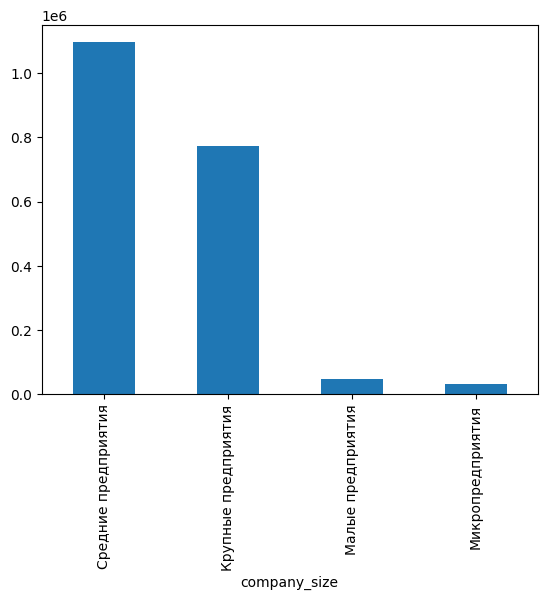

In [57]:
sample['company_size'].to_pandas().value_counts().plot.bar()

<Axes: xlabel='report_date'>

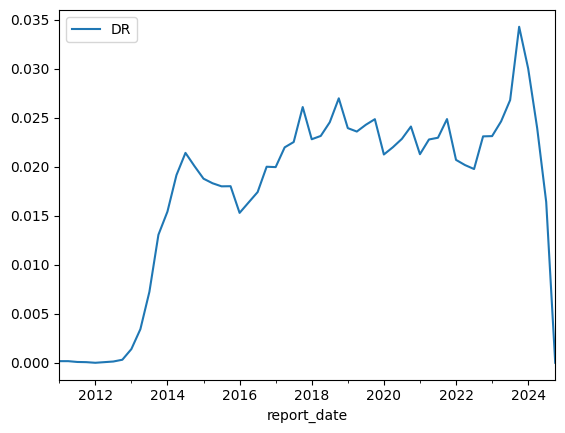

In [81]:
sample\
.with_columns(pl.date(pl.col('year'), pl.col('quarter')*pl.lit(3), 1).dt.month_end().alias('report_date'))\
.with_columns((pl.col('dissolution_date') < pl.col('report_date')).cast(pl.Int32).fill_null(0).alias('isdefault'))\
.with_columns((pl.col('report_date').dt.offset_by("1y") > pl.col('dissolution_date')).cast(pl.Int32).fill_null(0).alias('default_n_1'))\
.filter(pl.col('isdefault') == 0)\
.group_by('report_date')\
.agg(pl.col('default_n_1').mean().alias('DR'))\
.sort('report_date')\
.to_pandas()\
.set_index('report_date')\
.plot()

<Axes: xlabel='report_date'>

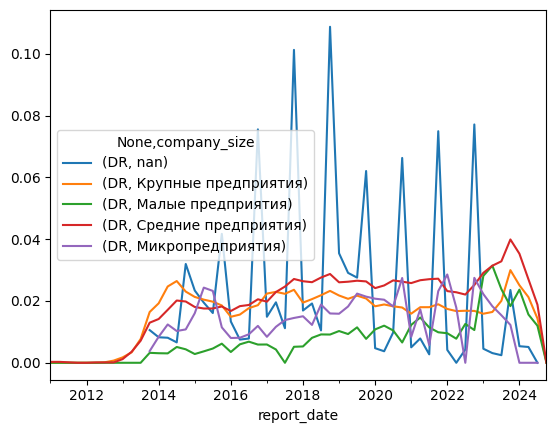

In [90]:
sample\
.with_columns(pl.date(pl.col('year'), pl.col('quarter')*pl.lit(3), 1).dt.month_end().alias('report_date'))\
.with_columns((pl.col('dissolution_date') < pl.col('report_date')).cast(pl.Int32).fill_null(0).alias('isdefault'))\
.with_columns((pl.col('report_date').dt.offset_by("1y") > pl.col('dissolution_date')).cast(pl.Int32).fill_null(0).alias('default_n_1'))\
.filter(pl.col('isdefault') == 0)\
.group_by(['company_size', 'report_date'])\
.agg(pl.col('default_n_1').mean().alias('DR'))\
.sort(['report_date', 'company_size'])\
.to_pandas()\
.set_index(['report_date', 'company_size'])\
.unstack()\
.plot()

<Axes: xlabel='quarter'>

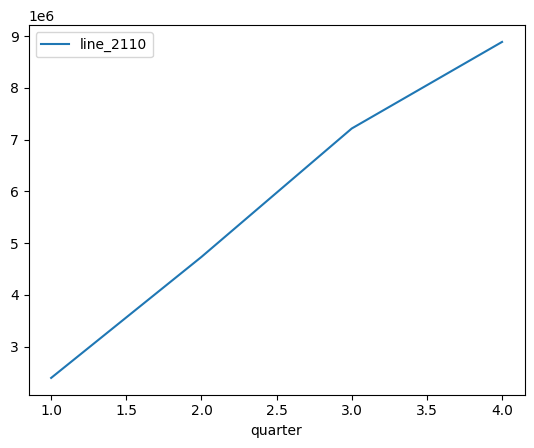

In [98]:
sample\
.group_by('quarter')\
.agg(pl.col('line_2110').mean())\
.sort('quarter')\
.to_pandas()\
.set_index('quarter')\
.plot()

In [92]:
sample.write_parquet('input/sample.parquet')

In [2]:
sample = pl.read_parquet('input/sample.parquet')

In [3]:
from sklearn.model_selection import train_test_split

def split_by_ogrn_balanced(
    df: pl.DataFrame,
    ogrn_col: str = 'ogrn',
    target_col: str = 'default',
    test_size: float = 0.2,
    random_state: int = 42
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """
    Split DataFrame by OGRN with no overlap and balanced by target column
    """
    ogrn_targets = df.group_by(ogrn_col).agg(
        pl.col(target_col).mode().first().alias('target')
    )
    
    ogrn_pd = ogrn_targets.to_pandas()
    
    train_ogrn, test_ogrn = train_test_split(
        ogrn_pd[ogrn_col],
        test_size=test_size,
        random_state=random_state,
        stratify=ogrn_pd['target']
    )
    
    # Split the original dataframe
    train_df = df.filter(pl.col(ogrn_col).is_in(train_ogrn))
    test_df = df.filter(pl.col(ogrn_col).is_in(test_ogrn))
    
    return train_df, test_df

In [4]:
train_df, test_df = split_by_ogrn_balanced(
    sample.with_columns((pl.col('dissolution_date') < pl.col('report_date')).cast(pl.Int32).fill_null(0).alias('default'))
)

In [14]:
train_df.write_parquet('input/train_df.parquet')
test_df.write_parquet('input/test_df.parquet')

In [7]:
set(train_df['ogrn']) & set(test_df['ogrn'])

set()

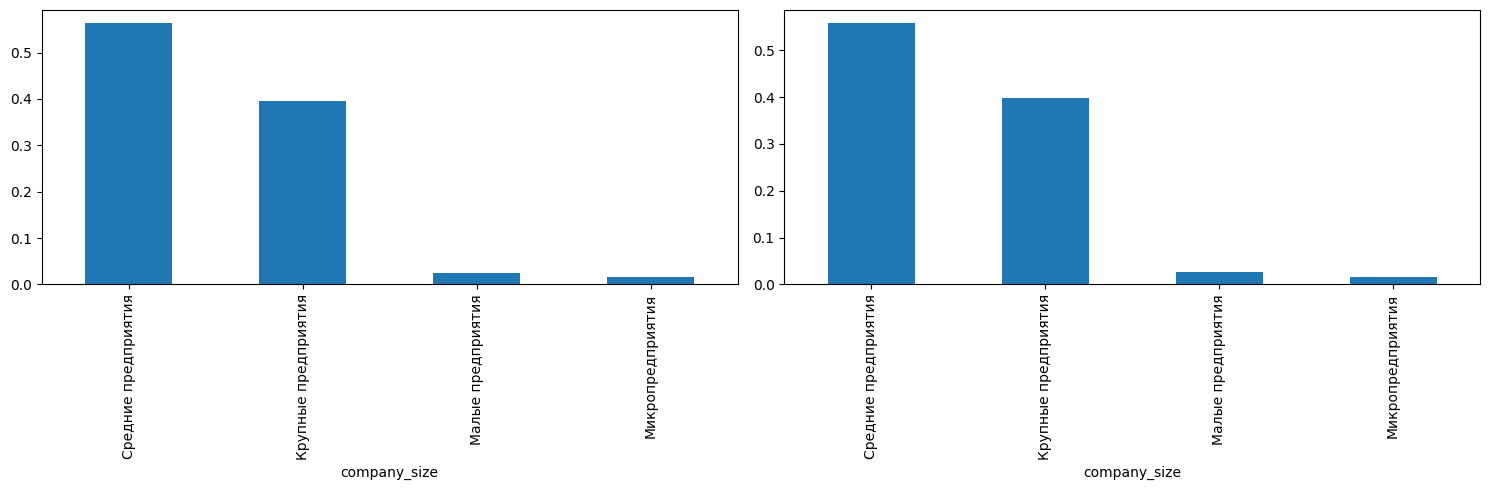

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
train_df['company_size'].to_pandas().value_counts(normalize=True).plot.bar(ax=ax[0])
test_df['company_size'].to_pandas().value_counts(normalize=True).plot.bar(ax=ax[1])

plt.tight_layout()
plt.show();

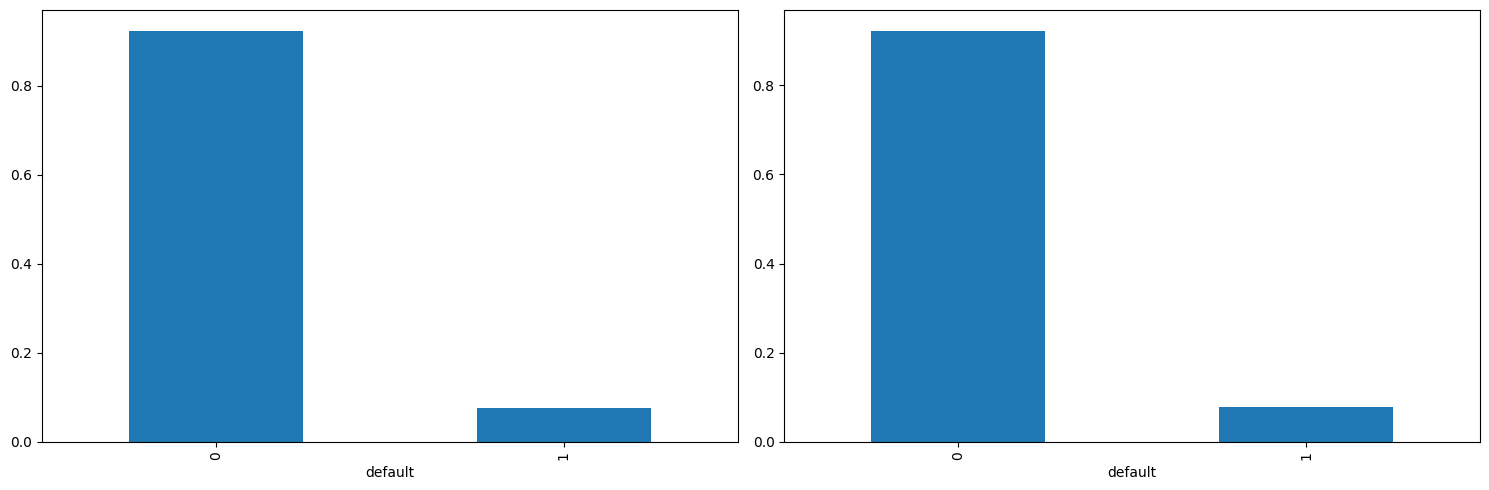

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
train_df['default'].to_pandas().value_counts(normalize=True).plot.bar(ax=ax[0])
test_df['default'].to_pandas().value_counts(normalize=True).plot.bar(ax=ax[1])

plt.tight_layout()
plt.show();

In [13]:
from huggingface_hub import login, upload_folder

In [ ]:
dataset = load_dataset("parquet", data_files={"train": "input/train_df.parquet", "test": "input/test_df.parquet"})
dataset.push_to_hub("Danisimmilian/GSOM_summer_school_Sber", token="")

In [21]:
data_check = load_dataset("Danisimmilian/GSOM_summer_school_Sber")

In [ ]:
data_check['train'].to_polars()